<a href="https://colab.research.google.com/github/DebanganRaj/data-science-project/blob/main/Breast_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#COMPLETE CLASSIFICATION PROJECT

##STEP 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from IPython.display import Markdown, display

##STEP 2: Load Dataset

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Target:

0 → Malignant

1 → Benign

##STEP 3: Check Dataset Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


##STEP 4: Handle Missing Values

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.fillna(df.mean(), inplace=True)

##STEP 5: Detect and Handle Outliers (IQR Method)

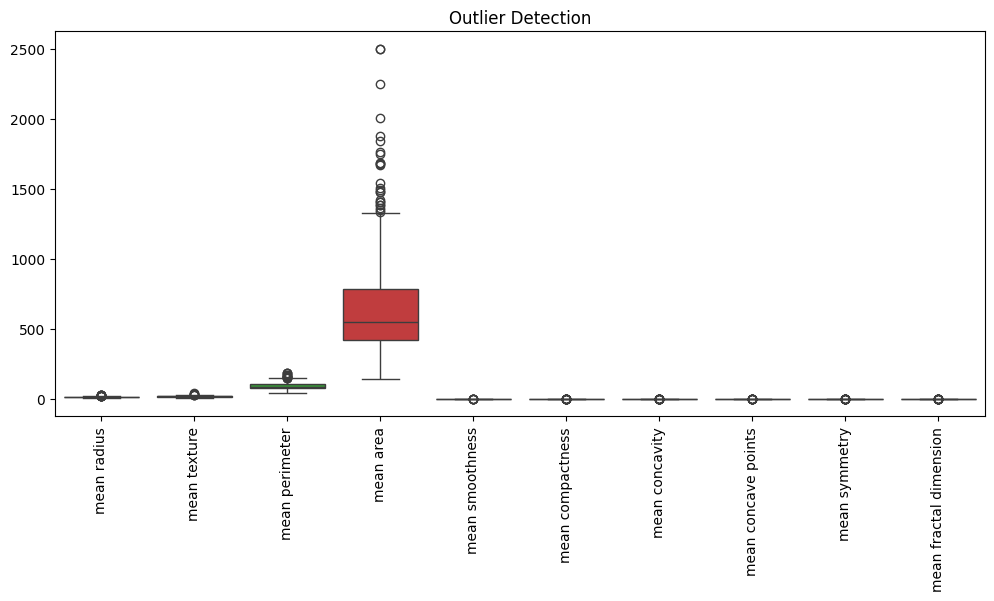

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df.iloc[:,:10])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

##STEP 6 — Outlier Removal (IQR Method)

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

##STEP 7 — FEATURE SELECTION

##Feature Selection Explanation

## Feature Selection

Feature selection selects the most important variables contributing
to prediction.

### Importance:
- Reduces overfitting
- Improves model accuracy
- Reduces computation time
- Improves interpretability

#Correlation-Based Feature Selection

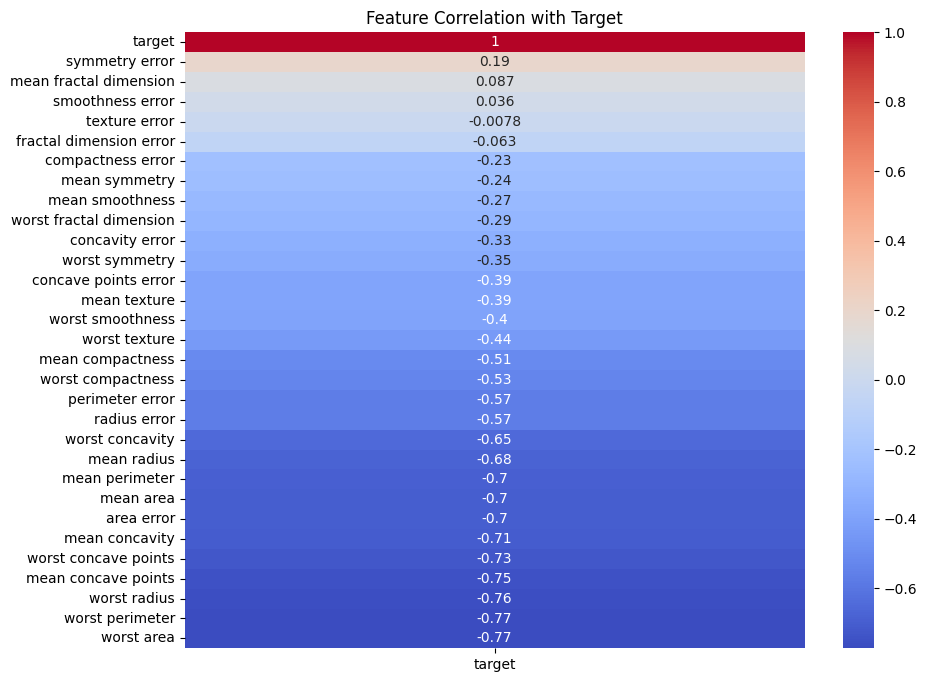

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False),
            annot=True,
            cmap='coolwarm')
plt.title("Feature Correlation with Target")
plt.show()

##Select Important Features

In [ ]:
selected_features = corr['target'].abs() > 0.5
selected_columns = corr.columns[selected_features]

df_selected = df[selected_columns]

df_selected.head()

,mean radius,mean perimeter,mean area,mean compactness,mean concavity,mean concave points,radius error,perimeter error,area error,worst radius,worst perimeter,worst area,worst compactness,worst concavity,worst concave points,target
6,18.25,119.6,1040.0,0.10900,0.11270,0.07400,0.4467,3.180,53.91,22.88,153.2,1606.0,0.2576,0.3784,0.19320,0
7,13.71,90.2,577.9,0.16450,0.09366,0.05985,0.5835,3.856,50.96,17.06,110.6,897.0,0.3682,0.2678,0.15560,0
10,16.02,102.7,797.8,0.06669,0.03299,0.03323,0.3795,2.466,40.51,19.19,123.8,1150.0,0.1551,0.1459,0.09975,0
11,15.78,103.6,781.0,0.12920,0.09954,0.06606,0.5058,3.564,54.16,20.42,136.5,1299.0,0.5609,0.3965,0.18100,0
13,15.85,103.7,782.7,0.10020,0.09938,0.05364,0.4033,2.903,36.58,16.84,112.0,876.5,0.1924,0.2322,0.11190,0


##STEP 8 — Define Features & Target

In [ ]:
X = df_selected.drop('target', axis=1)
y = df_selected['target']

##STEP 9 — Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

##STEP 10 — Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##STEP 11 — Train Classification Model

In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

##STEP 12 — Prediction

In [ ]:
y_pred = model.predict(X_test)

##STEP 13 — Confusion Matrix

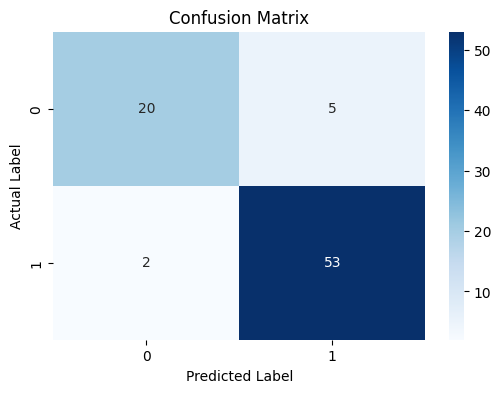

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

##STEP 14 — Evaluation Metrics Definition

## Model Evaluation Metrics

### Accuracy
Accuracy measures overall correctness of predictions.

### Precision
Precision measures how many predicted positive cases are truly positive.
Important when false positives are costly.

### Recall
Recall measures how many actual positive cases are detected.
Very important in medical diagnosis.

### F1 Score
F1-score balances Precision and Recall.
Useful when dataset is imbalanced.

##STEP 15 — Calculate Performance Metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9125
Precision: 0.9137931034482759
Recall   : 0.9636363636363636
F1 Score : 0.9380530973451328


##STEP 16 — Interpretation

High Accuracy → overall correct prediction

High Precision → fewer false alarms

High Recall → fewer missed cancer cases

High F1-score → balanced performance